In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('titanic.csv')

In [3]:
print(df.shape)
df.info()

(891, 13)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   PassengerId  891 non-null    int64  
 2   Survived     891 non-null    int64  
 3   Pclass       891 non-null    int64  
 4   Name         891 non-null    str    
 5   Sex          891 non-null    str    
 6   Age          714 non-null    float64
 7   SibSp        891 non-null    int64  
 8   Parch        891 non-null    int64  
 9   Ticket       891 non-null    str    
 10  Fare         891 non-null    float64
 11  Cabin        204 non-null    str    
 12  Embarked     889 non-null    str    
dtypes: float64(2), int64(6), str(5)
memory usage: 90.6 KB


One of the problems is the Unnamed: 0 column it is difficult to extract tthe meaning of the column. If we are unable to extract this meaning, it is difficult for us to know if this feature is important and if it impacts Survived.

In [7]:
df.isnull().sum()/ df.shape[0] * 100

Unnamed: 0      0.000000
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

From looking at this, the columns with missing values are Age, Cabin and Embarked. Cabin has 77% of the data missing, Age has 20% and Embarked has only 0.22% missing values.

In [4]:
df.describe()

,Unnamed: 0,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,445.000000,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,222.500000,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,445.000000,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,667.500000,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,890.000000,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


- One of the problems is that Age has a minimum value of 0.42. Even though you can have an Age of 0.42 but we typically talk about the Age of someone in terms of an integer so having an Age of 0.42 is something worth investigating.
- SibSp has a maximum value of 8. This is quite a large value but it is a value that is uncommon but not impossible. This is worth noting down but there are not any concerns.
- Similarly to SibSp, the Parch has a maximum value of 6. Again this is an uncommon value but not impossible since you could have 6 children that you went on the titanic with. Once again, this is worth noting down but not concerning.
- The minimum value of Fare is 0. This seems a little odd since to get a ticket you would have to pay some fee but it seems there is at least one case where this is not true. This is something that is worth investigating since it might be genuine that a passenger did not have to pay but we need to be confident before going further.

In [8]:
df_clean = df.copy()

In [12]:
df_clean['Age'] = df_clean['Age'].fillna(df['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df['Embarked'].mode())
df_clean = df_clean.drop(columns=['Cabin'])

I have imputted the missing values of Age with the median. I have imputted the Embarked with the mode. For the Cabin field, I have removed the column. My reason for removing this column is because there are a lot of missing values(nearly 80% are missing for that column). Also for the problem we are solving, Cabin is not so important in terms of Survived and if it is, we can capture the same pattern using the Pclass field.

Text(0.5, 1.0, 'Boxplot of Fare')

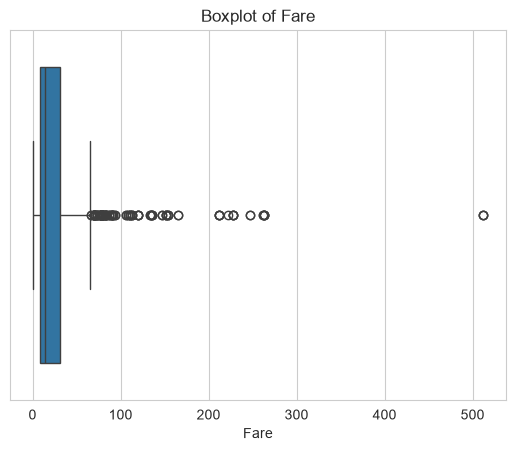

In [16]:
sns.boxplot(x = df_clean['Fare'])
plt.title('Boxplot of Fare')

From this plot, we can see there are outliers that are on the upper0end of Fare. This is indicated with the datapoints plotted on the right of the far whisker. These are values of Fare which are above the Upper-Quartile + 1.5 * Inter-Quartile Range.

In [29]:
def iqr_bounds(series):
    q1,q3 = series.quantile(0.25),series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

low_iqr, high_iqr = iqr_bounds(df_clean['Fare'])
print(f'Fare outlier bounds: {low_iqr:,.0f} to {high_iqr:,.0f}')
print('Fare outliers.', ((df_clean['Fare'] >  high_iqr) | (df_clean['Fare'] < low_iqr)).sum())

Fare outlier bounds: -27 to 66
Fare outliers. 116


In [30]:
def z_score_bounds(series):
    mean = series.mean()
    standard_deviation = series.std()
    return mean - 3 * standard_deviation, mean + 3 * standard_deviation

low_z_score, high_z_score = z_score_bounds(df_clean['Fare'])
print(f' Fare outlier bounds: {low_z_score:,.0f} to {high_z_score:,.0f}')
print('Fare outliers ', ((df_clean['Fare'] < low_z_score) | (df_clean['Fare'] > high_z_score)).sum())

 Fare outlier bounds: -117 to 181
Fare outliers  20


The reason why we have identified a different number of outliers for different methods is because when using the z_score test, it assumes that the column of data we are looking at follows a normal bell shaped distribution where the data is not skewed. The data column we are looking at is Fare and we can see that it is skewed since we have some extreme values on the higher end of the distribution. Median is 14 and mean is 32 so there are values that are large which is increasing our mean. Since our data is skewed, this increases our standard deviation so the z-score outlier range will be much larger. That is why we saw a significantly less outliers when looking at the z_score.

In [33]:
df_clean['Fare'] = df_clean['Fare'].clip(lower = low_iqr, upper = high_iqr)

Text(0.5, 1.0, 'Boxplot of log(1+ Fare)')

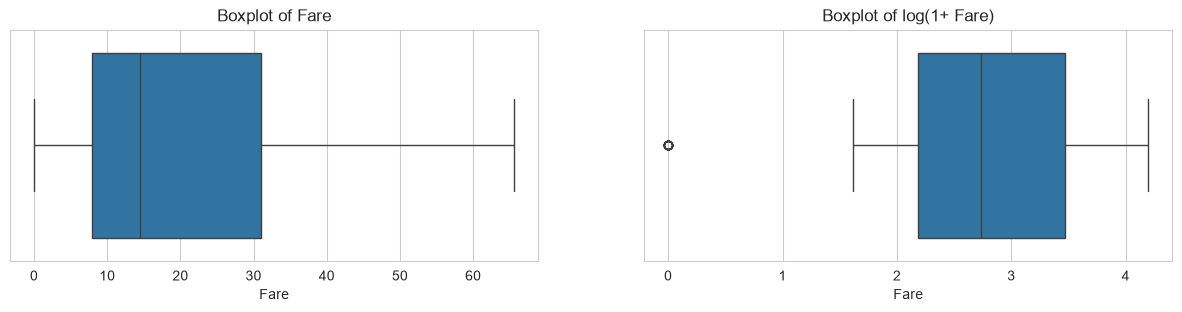

In [38]:
fig,axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15,3))
sns.boxplot(x = df_clean['Fare'],ax = axes[0])
axes[0].set_title('Boxplot of Fare')
sns.boxplot(x = np.log(1+ df_clean['Fare']), ax = axes[1])
axes[1].set_title('Boxplot of log(1+ Fare)')

Now that we have removed the extremly high outlier values for Fare, we see that all the values are between 0-66 for Fare. 